


Epoch 1/10


235/235 [==============================] - 25s 91ms/step - loss: 0.7079 - accuracy: 0.7739 - val_loss: 1.4932 - val_accuracy: 0.4914
Epoch 2/10
235/235 [==============================] - 20s 86ms/step - loss: 0.1870 - accuracy: 0.9474 - val_loss: 0.1632 - val_accuracy: 0.9543
Epoch 3/10
235/235 [==============================] - 16s 69ms/step - loss: 0.1361 - accuracy: 0.9612 - val_loss: 0.0603 - val_accuracy: 0.9822
Epoch 4/10
235/235 [==============================] - 17s 74ms/step - loss: 0.1123 - accuracy: 0.9678 - val_loss: 0.0482 - val_accuracy: 0.9858
Epoch 5/10
235/235 [==============================] - 22s 93ms/step - loss: 0.0943 - accuracy: 0.9739 - val_loss: 0.0551 - val_accuracy: 0.9827
Epoch 6/10
235/235 [==============================] - 22s 95ms/step - loss: 0.0865 - accuracy: 0.9758 - val_loss: 0.0386 - val_accuracy: 0.9879
Epoch 7/10
235/235 [==============================] - 23s 96ms/step - loss: 0.0786 - accuracy: 0.9782 - val_loss: 0.0590 - val_accu

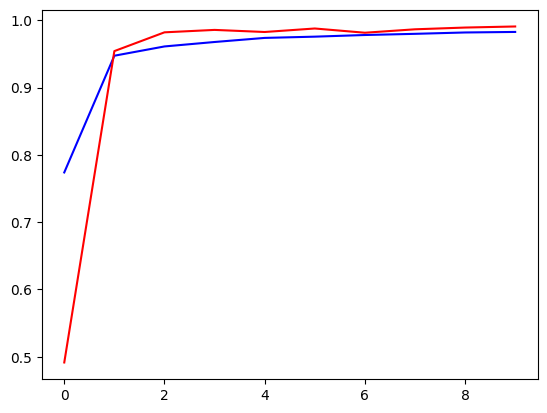

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist
import matplotlib.pyplot as plt 

(x_train, y_train),(x_test,y_test) = mnist.load_data()
x_train = x_train.reshape((-1,28,28,1)).astype('float32') / 255
x_test = x_test.reshape((-1,28,28,1)).astype('float32') / 255

# On doit spécifier input_shape seulement pour la première couche
# Elle doit savoir à quoi ressemble l’image d’entrée : largeur, hauteur, canaux (ici 28x28, en niveau de gris donc 1 canal)
model = keras.Sequential()
model.add(keras.layers.Conv2D(32,(3,3),input_shape=(28,28,1)))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.MaxPool2D((2,2)))

# Pas besoin d’input_shape car le modèle sait déjà à quoi ressemble la sortie de la couche précédente
model.add(keras.layers.Conv2D(32,(3,3)))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.MaxPool2D((2,2)))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(128,activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64,activation='relu'))
model.add(keras.layers.Dropout(0.3))

model.add(keras.layers.Dense(10,activation='softmax'))

model.compile(optimizer=tf.optimizers.Adam(),loss=tf.losses.sparse_categorical_crossentropy, metrics=['accuracy'])

hist = model.fit(x_train, y_train, epochs=10, batch_size=256, validation_data=(x_test,y_test))

plt.plot(hist.history['accuracy'],color= 'blue')
plt.plot(hist.history['val_accuracy'],color='red')
